# Linear regression with Python

The notebook builds a simple linear regression model that learns a relationship between two input features and a target value. It generates synthetic data from a known linear function, initializes random weights and bias, then uses a forward pass to compute predictions, a mean-squared error loss to measure fit, and gradient descent to update the parameters. The training loop repeatedly computes predictions, loss, gradients, and parameter updates so the model gradually approximates the true linear mapping from features to price.

In [ ]:
# install matplotlib for plotting in the notebook
!pip install matplotlib

In [303]:
import numpy as np  # import numpy for numerical computing
import pandas as pd  # import pandas for data manipulation
import matplotlib.pyplot as plt  # import plotting functions from matplotlib
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm


# Problem Setup

You can write the relationship with a 2-variable linear equation:


\begin{equation}
y = b + w_1.x_1 + w_2.x_2
\end{equation}

where

$x_i$ → input feature
$w_i$ → weight (what the model learns)
$b$ → bias (offset)
$y$ → target value


In a vector form:


\begin{equation}
y = b + (w_1 w_2).\binom{x_1}{x_2}
\end{equation}


where

\begin{equation}
W = (w_1 w_2)
\end{equation}

and

\begin{equation}
X = \binom{x_1}{x_2}
\end{equation}


# Generating Synthetic Data

In the synthetic data generation step, the function `generate_examples(num=1000)` creates a dataset of 1000 samples by first defining the true underlying relationship with parameters `W = [1.0, -3.0]` and `b = 1.0`. It then generates random input features X (with two variables per sample), typically drawn from a uniform or normal distribution. For each sample, the target value y is computed using the linear equation $y = 1.0 + (1.0x_1) + (-3.0 x_2)$, often with a small amount of random noise added to simulate real-world variability. This process produces a controlled dataset where the correct weights and bias are known in advance, allowing you to verify whether the model can successfully learn and recover these parameters during training.

In [253]:
def generate_examples(num=1000):
    # set true underlying weights and bias
    W = [1.0, -3.0]
    b = 1.0
    
    # reshape W to column vector for matrix multiplication
    W = np.reshape(W, (2,1))
    # sample input features from a standard normal distribution
    X = np.random.randn(num,2)
    
    # compute true targets using linear model y = b + X.W
    y = b + np.dot(X, W)
    
    # reshape output to a column vector
    y = np.reshape(y, (num,1))
    
    return X, y

In [254]:
# generate synthetic training examples using the helper function
X, y = generate_examples()

In [255]:
# display the shapes of the feature matrix and target vector
print(X.shape, y.shape)

(1000, 2) (1000, 1)


In [256]:
# print the first training sample (features and target)
print(X[0], y[0])

[ 0.77514343 -0.94747964] [4.61758236]


# Model Initialization

In this step, the `Model` class is created with `num_features=2`, and its parameters are initialized before training begins. Specifically, the weights W are set as a NumPy array with random values (one for each feature, matching the two inputs $x_1$ and $x_2$), and the bias b is initialized to 0 (or a small constant). This means the model starts with no prior knowledge of the true relationship $y = 1.0 + (1.0x_1) + (-3.0 x_2)$, so its initial predictions will be inaccurate. The purpose of this step is to provide a starting point for learning—these random weights and bias will be iteratively adjusted during training via gradient descent until they approximate the true parameters [1.0, -3.0] and 1.0.

The loss over **m** examples:


\begin{equation}
J = \frac{1}{2m} \sum_{i=1}^{m} (y - \hat{y})^2
\end{equation}


The objective of the gradient descent algorithm is to minimize this loss value.

Gradient Descent Objective is to 

\begin{equation}
min(J)
\end{equation}


In [257]:
class Model:
    def __init__(self, num_features):
        # number of features in the input data
        self.num_features = num_features
        # initialize weights randomly for each feature
        self.W = np.random.randn(num_features, 1)
        # initialize bias randomly as a scalar
        self.b = np.random.randn()


In [258]:
# create a model instance with two input features
model = Model(2)
# print the initial random weights and bias
print(model.W)
print(model.b)


[[0.21059382]
 [0.04523159]]
-0.17991875573378024


# Forward Pass (Prediction)

The gradient descent algorithm can be simplified in 4 steps:
1. Get predictions $\hat{y}$ for X with current values of W and b.

\begin{equation}
\hat{y_i}=Wx_i+b \qquad i = 1, 2, ..., n
\end{equation}

2. Compute classical linear regression cost function between y and $\hat{y}$.

\begin{equation}
J(W,b) = \frac{1}{2m}\sum_{i=1}^{m}(y_i - \hat{y}_i)^2 = \frac{1}{2m}\sum_{i=1}^{m}[y_i - (Wx_i+b)]^2
\end{equation}

3. Find gradients of the loss with respect to parameters W and b.

\begin{equation}
\frac{\partial J}{\partial W} = - \frac{1}{m}\sum_{i=1}^{n}x_i[y_i - (Wx_i+b)]
\end{equation}

\begin{equation}
\frac{\partial J}{\partial b} = - \frac{1}{m}\sum_{i=1}^{n}[y_i - (Wx_i+b)]
\end{equation}

4. Update the values of W and b by subtracting the gradient values obtained in the previous step, using the learning rate α.

\begin{equation}
W^{(t+1)} = W^{t} - \alpha \frac{\partial L}{\partial W}
\end{equation}

\begin{equation}
b^{(t+1)} = b^{t} - \alpha \frac{\partial L}{\partial b}
\end{equation}

In [259]:
class Model(Model):
    def forward_pass(self, X):
        # compute predicted values using current weights and bias
        y_hat = self.b + np.dot(X, self.W)
        return y_hat


In [260]:
# run a forward pass with a new model instance and print the output shape and sample
y_hat = Model(2).forward_pass(X)
print(y_hat.shape, y_hat[0])


(1000, 1) [0.7356754]


# Loss Function (How wrong is the model?)

The loss over **m** examples:


\begin{equation}
J = \frac{1}{2m} \sum_{i=1}^{m} (y - \hat{y})^2
\end{equation}

In [261]:
class Model(Model):
    def compute_loss(self, y_hat, y_true):
        # compute mean squared error loss over the batch
        return np.sum(np.square(y_hat - y_true))/(2*y_hat.shape[0])


In [262]:
# create a fresh model instance for loss evaluation
model = Model(2)
# generate predictions using the current random model
y_hat = model.forward_pass(X)
# compute the loss of these predictions against true values
loss = model.compute_loss(y_hat, y)


In [263]:
# display the computed loss value
loss


np.float64(7.059137254575562)

# Backward Pass (Compute Gradients)

The gradient of loss with respect to bias can be calculated with:

\begin{equation}
\frac{dJ}{db} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})
\end{equation}

\begin{equation}
\frac{dJ}{dW_j} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)}).x_j^{(i)}
\end{equation}

In [264]:
class Model(Model):
    def backward_pass(self, X, y_true, y_hat):
        # number of training examples in the batch
        m = y_true.shape[0]
        # gradient of loss with respect to bias
        db = (1/m)*np.sum(y_hat - y_true)
        # gradient of loss with respect to weights
        dW = (1/m)*np.sum(np.dot(np.transpose(y_hat - y_true), X), axis=0)
        return dW, db


In [265]:
# create a fresh model and compute gradients on the generated data
model = Model(2)
x, y = generate_examples()
y_hat = model.forward_pass(X)
dW, db = model.backward_pass(X, y, y_hat)


Gradients tell which direction reduces error.

In [266]:
# print the computed gradients for weights and bias
print(dW, db)


[-0.31206711  0.95159652] -1.8634713529378324


# Update Parameters (Gradient Descent)

In this step, the model improves its predictions by adjusting the weights W and bias b using the gradients computed during the backward pass. Specifically, each parameter is updated using the rules `W = W - lr * dW` and `b = b - lr * db`, where `lr` is the learning rate (a small positive value controlling step size), and `dW` and `db` represent how much each parameter contributed to the prediction error. The subtraction means the model moves in the opposite direction of the gradient, which is the direction that reduces the loss. Over many iterations, these incremental updates gradually shift the parameters from their initial random values toward the true values [1.0, -3.0] and 1.0, minimizing the error between predicted and actual outputs.

In [267]:
class Model(Model):
    def update_params(self, dW, db, lr):
        # update weights using gradient descent step
        self.W = self.W - lr * np.reshape(dW, (self.num_features, 1))
        # update bias using gradient descent step
        self.b = self.b - db


# Training Loop

Each iteration does:

1. Forward pass → predictions
2. Compute loss
3. Backward pass → gradients
4. Update parameters

In [268]:
class Model(Model):
    def train(self, X_train, y_train, iterations, lr):
        # collect loss values over training iterations
        losses = []
        for i in range(0, iterations):
            # compute predictions for the current batch
            y_hat = self.forward_pass(X_train)
            # compute current loss
            loss = self.compute_loss(y_hat, y_train)
            # compute gradients with respect to parameters
            dW, db = self.backward_pass(X_train, y_train, y_hat)
            # update parameters using the gradients
            self.update_params(dW, db, lr)
            losses.append(loss)
            if i % int(iterations/10) == 0:
                print(f"Iteration: {i}, Loss: {loss:4f}")
        return losses


In [269]:
# create a new model instance for training
model = Model(2)


In [270]:
# generate training data for the model
X_train, y_train = generate_examples()


In [271]:
# train the model for 1000 iterations with a small learning rate
losses = model.train(X_train, y_train, 1000, 3e-3)


Iteration: 0, Loss: 10.609166
Iteration: 100, Loss: 5.966098
Iteration: 200, Loss: 3.366726
Iteration: 300, Loss: 1.899879
Iteration: 400, Loss: 1.072123
Iteration: 500, Loss: 0.605012
Iteration: 600, Loss: 0.341416
Iteration: 700, Loss: 0.192666
Iteration: 800, Loss: 0.108724
Iteration: 900, Loss: 0.061355


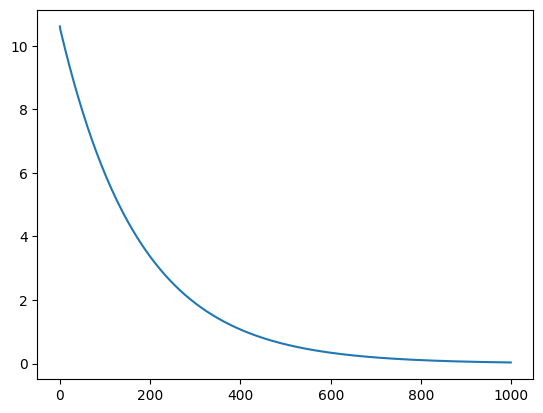

In [272]:
# plot the training loss curve to observe convergence
plt.plot(losses)


# Predictions

In [273]:
# create an untrained model to compare against the trained one
model_untrained = Model(2)

# generate a new test dataset
X_test, y_test = generate_examples(500)
print(X_test.shape, y_test.shape)


(500, 2) (500, 1)


In [274]:
# compute predictions from both the untrained and trained models
preds_untrained = model_untrained.forward_pass(X_test)
preds_trained = model.forward_pass(X_test)


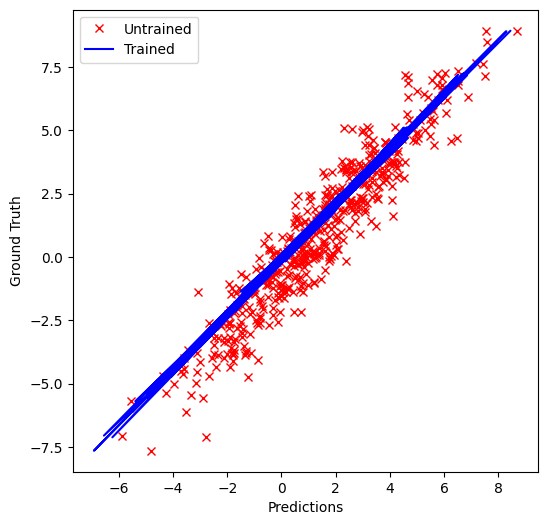

In [275]:
# plot predicted values against true targets for both models
plt.figure(figsize=(6, 6))
plt.plot(preds_untrained, y_test, 'rx', label='Untrained')
plt.plot(preds_trained, y_test, 'b', label='Trained')
plt.legend()
plt.xlabel('Predictions')
plt.ylabel('Ground Truth')
plt.show()


# Regression performance

In [293]:
y_pred = preds_trained
residuals = y_test - y_pred

In [294]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
bias = np.mean(y_pred - y_test)

print("Performance metrics")
print("-------------------")
print(f"R²    : {r2:.4f}")
print(f"MAE   : {mae:.4f}")
print(f"MSE   : {mse:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"MAPE  : {mape:.2f}%")
print(f"Bias  : {bias:.4f}")

Performance metrics
-------------------
R²    : 0.9928
MAE   : 0.2036
MSE   : 0.0644
RMSE  : 0.2537
MAPE  : 26.87%
Bias  : 0.0079


# Regression diagnostics

## Test residual normality: Shapiro-Wilk Test

H₀: Residuals have normal distribution.  
H₁: Residuals does not have normal distribution.

A high p-value (typically > 0.05) means you do NOT reject the null hypothesis; there is no evidence that your data deviates from normality.

In [298]:
shapiro_stat, shapiro_p = shapiro(residuals)

print("\nShapiro-Wilk Test")
print(f"Statistic: {shapiro_stat:.4f}")
print(f"P-value: {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("Residuals are approximately normal.")
else:
    print("Residuals are not normally distributed.")


Shapiro-Wilk Test
Statistic: 0.9980
P-value: 0.8282
Residuals are approximately normal.


<Figure size 600x600 with 0 Axes>

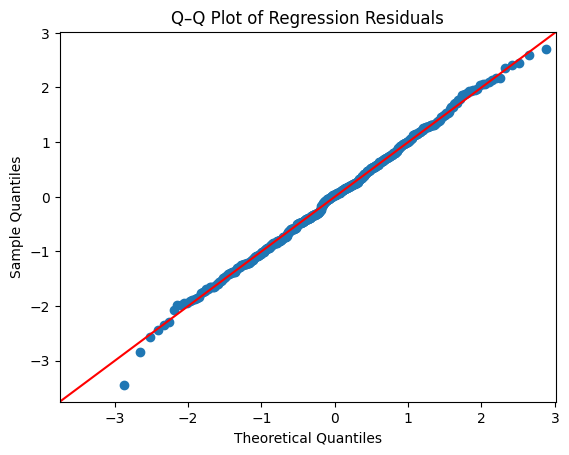

In [310]:
# Q–Q Plot of residuals
plt.figure(figsize=(6, 6))

sm.qqplot(
    residuals,
    line='45',     # Reference line
    fit=True
)

plt.title("Q–Q Plot of Regression Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")

plt.show()

## Test homoscedasticity: Breusch-Pagan Test

H₀: Residuals have constant variance (homoscedasticity).
H₁: Residual variance changes with predictors (heteroscedasticity).
A hight p-value (typically > 0.05) means you fail to reject the null hypothesis.

In [300]:
X_bp = sm.add_constant(X_test)

bp = het_breuschpagan(residuals, X_bp)

print("\nBreusch-Pagan Test")
print(f"LM Statistic: {bp[0]:.4f}")
print(f"P-value: {bp[1]:.4f}")

if bp[1] > 0.05:
    print("Homoscedasticity assumption satisfied.")
else:
    print("Evidence of heteroscedasticity detected.")


Breusch-Pagan Test
LM Statistic: 1.5684
P-value: 0.4565
Homoscedasticity assumption satisfied.


## Test independence of residuals: Durbin-Watson Test

The DW test evaluates autocorrelation of residuals, specifically first‑order autocorrelation. The statistic ranges from 0 to 4:
- $\approx 2.0$: No autocorrelation
- $< 2.0$: Positive autocorrelation
- $> 2.0$: Negative autocorrelation

In [301]:
dw = durbin_watson(residuals)

print("\nDurbin-Watson")
print(f"Statistic: {dw:.4f}")

if 1.5 <= dw <= 2.5:
    print("Residuals are approximately independent.")
else:
    print("Possible autocorrelation detected.")


Durbin-Watson
Statistic: 1.8998
Residuals are approximately independent.


## Check multicollinearity: Variance Inflation Factor (VIF)

VIF tells you whether your independent variables are highly correlated with each other. This problem is known as multicollinearity, which makes coefficient estimates unstable and inflates their variance.
How to interpret VIF values:
- VIF = 1: no multicollinearity
- VIF between 1 and 5: low to moderate multicollinearity (usually acceptable)
- VIF > 5: potential problem
- VIF > 10: serious multicollinearity issue

In [305]:
X_vif = pd.DataFrame(X_train)
X_vif = sm.add_constant(X_vif)

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print("\nVariance Inflation Factor")
print("-------------------------")
print(vif)


Variance Inflation Factor
-------------------------
  Variable       VIF
0    const  1.000699
1        0  1.000016
2        1  1.000016


## Detect influential observations: Cook's Distance

A common rule of thumb:
- Cook’s D < 0.5 → usually safe
- Cook’s D > 1.0 → highly influential
- Cook’s D > 4/n → potentially influential (your threshold)

In [309]:
ols_model = sm.OLS(
    y_train,
    sm.add_constant(X_train)
).fit()

influence = ols_model.get_influence()
cooks_distance = influence.cooks_distance[0]
threshold = 4 / len(X_train)

print("\nCook's Distance")
print("----------------")
print(f"Maximum value : {cooks_distance.max():.4f}")
print(f"Threshold     : {threshold:.4f}")

if cooks_distance.max() > threshold:
    print("Potential influential observations detected.")
else:
    print("No highly influential observations detected.")


Cook's Distance
----------------
Maximum value : 0.0403
Threshold     : 0.0040
Potential influential observations detected.


## Statistical significance of the regression

| Property | Statistics to observe | Result | Conclusion |
| --- | --- | --- | --- |
| Perfect linearity | R², residuals | R² ≈ 1.000 | Perfect fit |
| Perfect specification | F‑statistic, residual diagnostics | F huge, all tests passed | Correct model |
| No multicollinearity | VIF, Condition Number | VIF ≈ 1, CN ≈ 1 | No multicollinearity |
| Homoscedasticity | Breusch–Pagan | p > 0.05 | Constant variance |
| No autocorrelation | Durbin–Watson | DW ≈ 2 | Independent residuals |
| Normal residuals | Shapiro–Wilk, JB, Omnibus | All p > 0.05 | Normal residuals |
| Coefficients correct | Coefs, SE, CI | Exact values | True DGP recovered |

In [311]:
print("\nOLS Regression Summary")
print("----------------------")

# Includes:
# - F-test for overall model significance
# - t-tests for regression coefficients
# - p-values
# - confidence intervals
# - adjusted R²

print(ols_model.summary())


OLS Regression Summary
----------------------
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.297e+33
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:01:41   Log-Likelihood:                 32752.
No. Observations:                1000   AIC:                        -6.550e+04
Df Residuals:                     997   BIC:                        -6.548e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const